## runMSLM_ice
Prediction of pan-Arctic sea ice extent using DAHD + MSLM forecasting.

**Pipeline:**
1. Read and preprocess Arctic sea ice extent data from Excel.
2. Build 7 regional composites and trim to analysis period.
3. Plot raw sea ice extent (Fig 1).
4. Center data, remove seasonal cycle, compute anomalies.
5. Run DAHD spectral analysis — spectrum (Fig 2) and space-time modes (Figs 3-4).
6. Run MSLM stochastic forecast over 20 frequency bins with 600 ensemble members.
7. Post-process: add back seasonal cycle, zero negative SIE, compute anomalies.
8. Plot forecast vs observations (Fig 5), September prediction summary, histogram.

**Dependencies:** `DAHD4freq_part_weight`, `DAHM4_ex`, `MSLM_FCST`, `dahc`, `hrc`

**Data files required:** `N_Sea_Ice_Index_Regional_Daily_Data_G02135-2024June17.xlsx`, `ROBSF.mat`

**References:**
- Kondrashov D. et al. 2026: *Accurate and robust real-time prediction of September Arctic sea ice.* Chaos, 36. doi:10.1063/5.0295634

In [37]:
import importlib
import MSLM_FCST
importlib.reload(MSLM_FCST)
from MSLM_FCST import MSLM_FCST
print("reloaded!")

reloaded!


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import interp1d
import openpyxl

from DAHD4freq_part_weight import DAHD4freq_part_weight
from DAHM4_ex import DAHM4_ex
from MSLM_FCST import MSLM_FCST
from dahc import dahc
from hrc import hrc

### 1. Read Arctic Sea Ice Data
Read 14 Extent sheets from Excel. For each year column, compute 52 weekly means from 364 daily values, then stack all years sequentially.

In [39]:
EXCEL_FILE = 'N_Sea_Ice_Index_Regional_Daily_Data_G02135-2024June17.xlsx'
wb         = openpyxl.load_workbook(EXCEL_FILE, data_only=True)
sheet_idx  = list(range(1, 28, 2))   # 14 Extent sheets (0-indexed: 1,3,5,...,27)

all_weekly = []
for si in sheet_idx:
    ws     = wb.worksheets[si]
    rows   = list(ws.iter_rows(values_only=True))
    header = rows[0]
    n_yr   = len([c for c in header[2:] if isinstance(c, (int, float))])
    num0   = []
    for row in rows[1:365]:
        num0.append([
            float(v) if isinstance(v, (int, float)) and v is not None else np.nan
            for v in row[2:2 + n_yr]
        ])
    num0   = np.array(num0, dtype=float)
    weekly = np.zeros((52, n_yr))
    for yr in range(n_yr):
        weekly[:, yr] = num0[:, yr].reshape(52, 7).mean(axis=1)
    all_weekly.append(weekly.T.reshape(-1))

max_len = max(len(a) for a in all_weekly)
extent  = np.full((max_len, 14), np.nan)
for k, a in enumerate(all_weekly):
    extent[:len(a), k] = a

print(f"extent shape: {extent.shape}")

extent shape: (2444, 14)


### 2. Interpolate Missing Values and Build Regional Composites

In [40]:
data = np.copy(extent)
for kk in range(14):
    tmp  = extent[:, kk]
    indm = np.where(np.isnan(tmp))[0]
    indf = np.where(~np.isnan(tmp))[0]
    if len(indm) > 0 and len(indf) > 1:
        f = interp1d(indf, tmp[indf], bounds_error=False, fill_value='extrapolate')
        data[indm, kk] = f(indm)

nan_ind      = np.where(np.isnan(data[:, 0]))[0]
NN           = nan_ind[0] if len(nan_ind) > 0 else data.shape[0]
data         = data[:NN - 1, :]
data[-1, 13] = data[-2, 13]

iceCEN = data[:, 5]
iceA   = data[:, 2]  + data[:, 6]
iceB   = data[:, 4]
iceC   = data[:, 1]  + data[:, 10]
iceD   = data[:, 11] + data[:, 7]
iceE   = data[:, 0]
iceF   = data[:, 8]
iceG   = data[:, 3]  + data[:, 9] + data[:, 12] + data[:, 13]

ICET      = np.column_stack([iceA, iceB, iceC, iceD, iceE + iceF, iceG])
iceextobs = np.column_stack([iceCEN, ICET])
DD        = iceextobs.shape[1]

iceextobs = iceextobs[1404:, :]
iceext    = iceextobs.copy()
weeks     = np.arange(1, iceext.shape[0] + 1)
yearst    = 2006 + weeks / 52
print(f"iceextobs shape: {iceextobs.shape}, DD={DD}")

iceextobs shape: (1039, 7), DD=7


### Fig 1 — Raw Sea Ice Extent
Melt curves weeks 20-40 for 7 regions + pan-Arctic. Red = historical, blue = last year, green = 2012 minimum, black = current year.

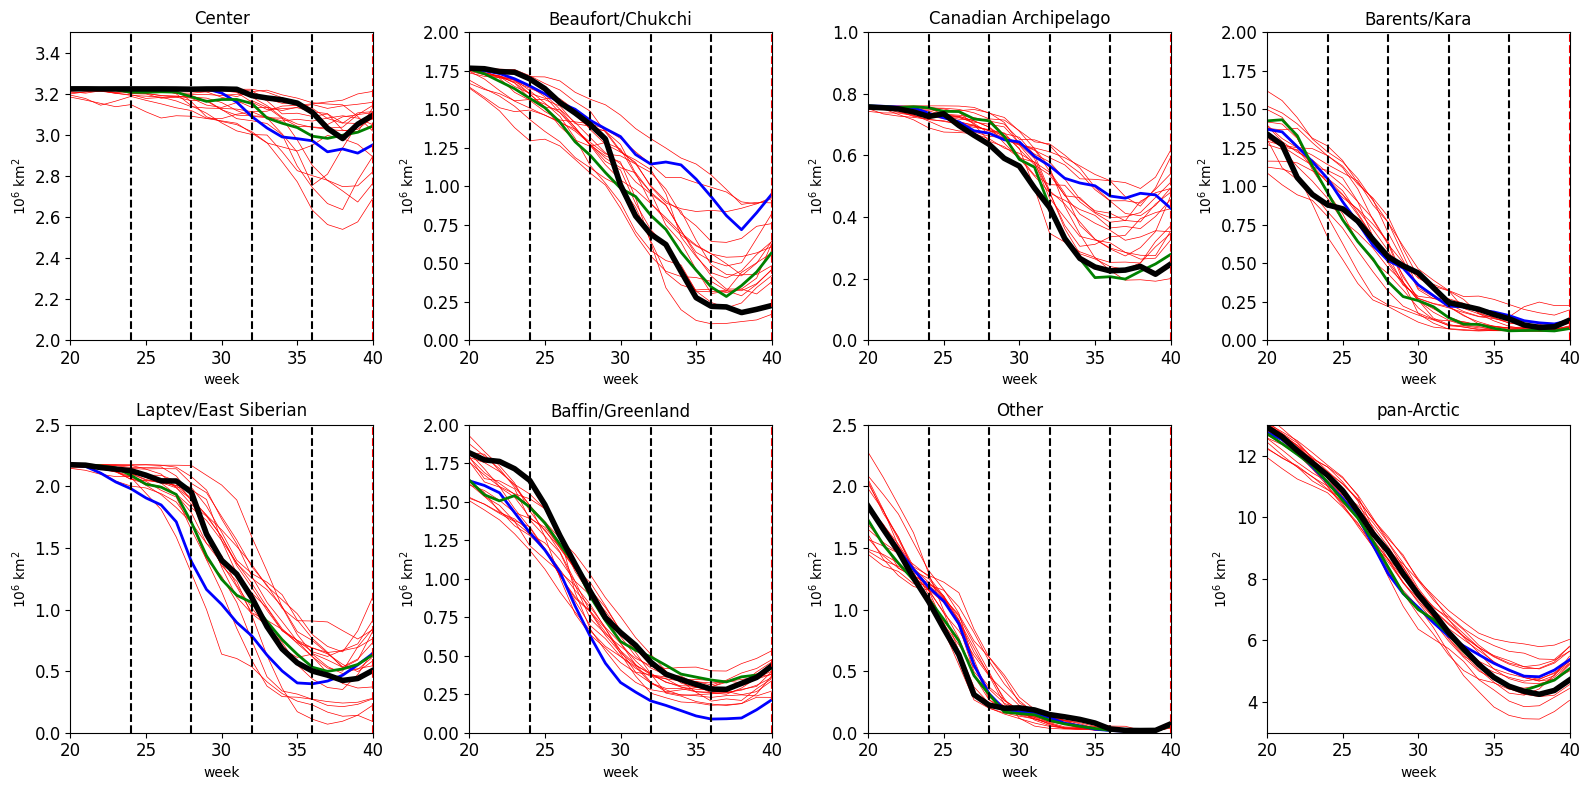

In [41]:
n_hist  = 728 + 52 * 4
n_years = n_hist // 52
iceyear = iceextobs[:n_hist, :].reshape(n_years, 52, DD).transpose(1, 0, 2)
ice2021 = iceextobs[n_hist:, :]
tweek   = ice2021.shape[0]

titles = ['Center', 'Beaufort/Chukchi', 'Canadian Archipelago',
          'Barents/Kara', 'Laptev/East Siberian', 'Baffin/Greenland', 'Other']
ylims  = [(2, 3.5), (0, 2), (0, 1), (0, 2), (0, 2.5), (0, 2), (0, 2.5)]
wk_slice = slice(19, 40)
x_weeks  = np.arange(20, 41)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for k in range(DD):
    ax = axes.flat[k]
    ax.plot(x_weeks, iceyear[wk_slice, :, k] / 1e6, 'r', linewidth=0.5)
    ax.plot(x_weeks, iceyear[wk_slice, -2, k] / 1e6, 'b', linewidth=2)
    ax.plot(x_weeks, iceyear[wk_slice,  6, k] / 1e6, 'g', linewidth=2)
    n_cur = min(tweek - 19, len(x_weeks))
    if n_cur > 0:
        ax.plot(x_weeks[:n_cur], ice2021[19:19 + n_cur, k] / 1e6, 'k', linewidth=4)
    ax.axvline(min(tweek, 40), color='r', linestyle='--')
    for wk in [24, 28, 32, 36]:
        if tweek > wk: ax.axvline(wk, color='k', linestyle='--')
    ax.set_title(titles[k] if k < len(titles) else f'Region {k+1}')
    ax.set_xlim([20, 40]); ax.set_xlabel('week'); ax.set_ylabel('10$^6$ km$^2$')
    if k < len(ylims): ax.set_ylim(ylims[k])
    ax.tick_params(labelsize=12)

ax = axes.flat[7]
ax.plot(x_weeks, np.sum(iceyear[wk_slice, :, :], axis=2)           / 1e6, 'r', linewidth=0.5)
ax.plot(x_weeks, np.sum(iceyear[wk_slice, -2, :], axis=1)          / 1e6, 'b', linewidth=2)
ax.plot(x_weeks, np.sum(iceyear[wk_slice,  6, :], axis=1)          / 1e6, 'g', linewidth=2)
n_cur = min(tweek - 19, len(x_weeks))
if n_cur > 0:
    ax.plot(x_weeks[:n_cur], np.sum(ice2021[19:19+n_cur, :], axis=1) / 1e6, 'k', linewidth=4)
ax.set_title('pan-Arctic'); ax.set_xlim([20, 40]); ax.set_ylim([3, 13])
ax.set_xlabel('week'); ax.set_ylabel('10$^6$ km$^2$'); ax.tick_params(labelsize=12)
plt.tight_layout(); plt.show()

### 3. Forecast Setup and Seasonal Cycle Removal

In [42]:
TARG = 767 + 4 * 52
KT   = iceext.shape[0]
LEAD = TARG - KT
KF   = KT

yearst_full = np.append(yearst, np.arange(1, LEAD + 1) / 52 + yearst[KF - 1])
iceext  = iceextobs[:KF, :]
icemean = np.mean(iceext, axis=0)

iceext_c = iceext - icemean
anom     = np.zeros_like(iceext_c)
scycle   = np.zeros((52, DD))
icycle   = 1

for j in range(DD):
    for i in range(52):
        idx           = np.arange(i, iceext_c.shape[0], 52)
        scycle[i, j]  = np.mean(iceext_c[idx, j])
        anom[idx, j]  = iceext_c[idx, j] - scycle[i, j]

X = anom
print(f"X shape: {X.shape}, LEAD={LEAD}")

X shape: (1039, 7), LEAD=-64


### Fig 2 — DAHD Spectrum
Eigenvalue spectrum vs frequency. High values at low frequencies show dominant seasonal cycles in Arctic sea ice data.

Running DAHD spectral analysis...
0 >0:7 <0:0
1 >0:7 <0:0
2 >0:7 <0:0
3 >0:7 <0:0
4 >0:7 <0:0
5 >0:7 <0:0
6 >0:7 <0:0
7 >0:7 <0:0
8 >0:7 <0:0
9 >0:7 <0:0
10 >0:7 <0:0
11 >0:7 <0:0
12 >0:7 <0:0
13 >0:7 <0:0
14 >0:7 <0:0
15 >0:7 <0:0
16 >0:7 <0:0
17 >0:7 <0:0
18 >0:7 <0:0
19 >0:7 <0:0
20 >0:7 <0:0
21 >0:7 <0:0
22 >0:7 <0:0
23 >0:7 <0:0
24 >0:7 <0:0
25 >0:7 <0:0
26 >0:7 <0:0
27 >0:7 <0:0
28 >0:7 <0:0
29 >0:7 <0:0
30 >0:7 <0:0
31 >0:7 <0:0
32 >0:7 <0:0
33 >0:7 <0:0
34 >0:7 <0:0
35 >0:7 <0:0
36 >0:7 <0:0
37 >0:7 <0:0
38 >0:7 <0:0


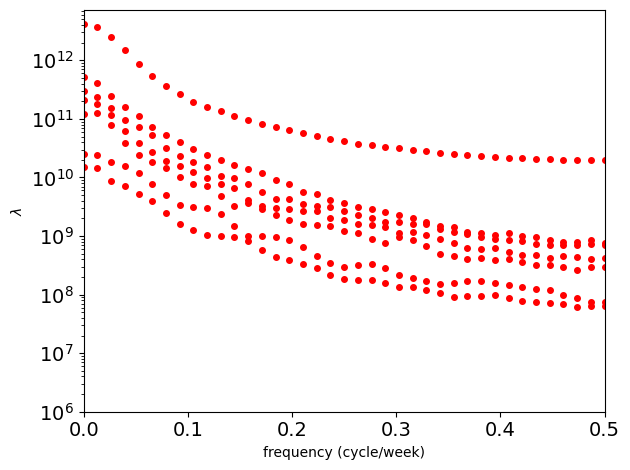

In [43]:
W   = 39
WW  = 2 * W - 1
D   = X.shape[1]
NP  = D
NFE = W
wt  = 'bartlett'

print("Running DAHD spectral analysis...")
fE2, VP, FEP = DAHD4freq_part_weight(X, W, NFE, NP, wt)

plt.figure()
plt.semilogy(fE2, np.abs(VP).T, 'ro', markersize=4, markerfacecolor='r')
plt.ylabel(r'$\lambda$'); plt.xlim([0, 0.5]); plt.ylim(bottom=1e6)
plt.xlabel('frequency (cycle/week)'); plt.tick_params(labelsize=14)
plt.tight_layout(); plt.show()

### Compute Space-Time DAHMs

In [44]:
NP = D
EP = np.zeros(((2 * W - 1) * D, 2 * NP, NFE))
print("Computing DAHMs...")
for iff in range(NFE):
    ER  = DAHM4_ex(FEP[:, :, iff], W, iff, 2 * NP)
    EP[:, :, iff] = np.reshape(ER, ((2 * W - 1) * D, 2 * NP))
print(f"EP shape: {EP.shape}")

Computing DAHMs...
EP shape: (539, 14, 39)


### Fig 3 — DAHM Eigenvectors (f=0.11-0.20)
Space-time structure of 8 leading DAHM pairs at mid-range frequencies.

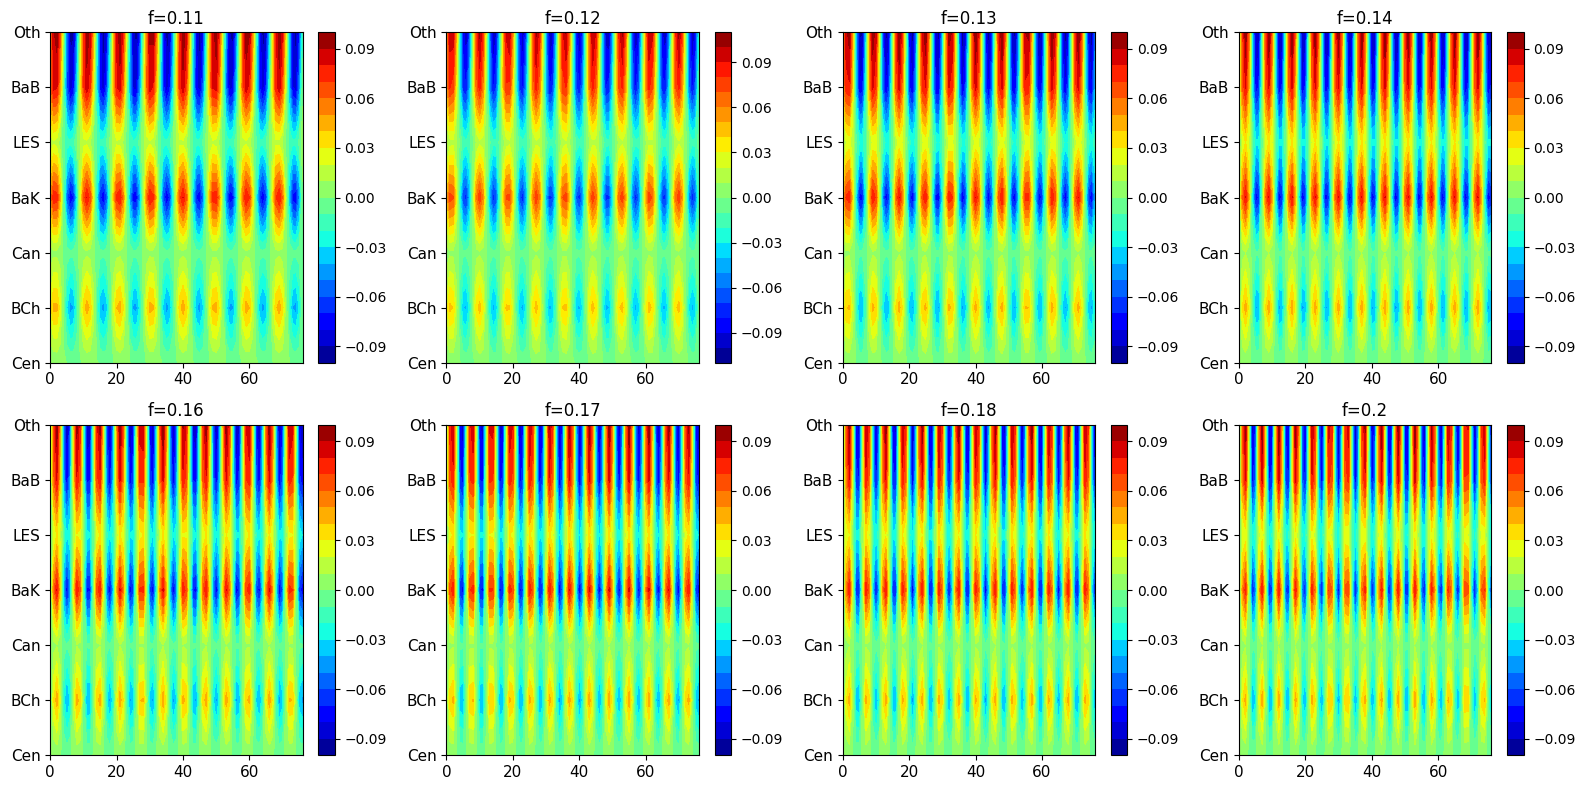

In [45]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for NFFF, NF in enumerate(range(8, 16)):
    ax = axes.flat[NFFF]
    cf = ax.contourf(np.reshape(EP[:, 1, NF], (WW, D)).T, 20, cmap='jet')
    plt.colorbar(cf, ax=ax)
    ax.set_title(f'f={round(fE2[NF], 2)}')
    ax.set_yticks(range(D))
    ax.set_yticklabels(['Cen', 'BCh', 'Can', 'BaK', 'LES', 'BaB', 'Oth'][:D])
    ax.tick_params(labelsize=11)
plt.tight_layout(); plt.show()

### Fig 4 — DAHM Eigenvector Pairs (4x4 grid)
Rows 1-2: first eigenvector at odd frequencies; rows 3-4: quadrature pair. Each pair is in exact phase quadrature.

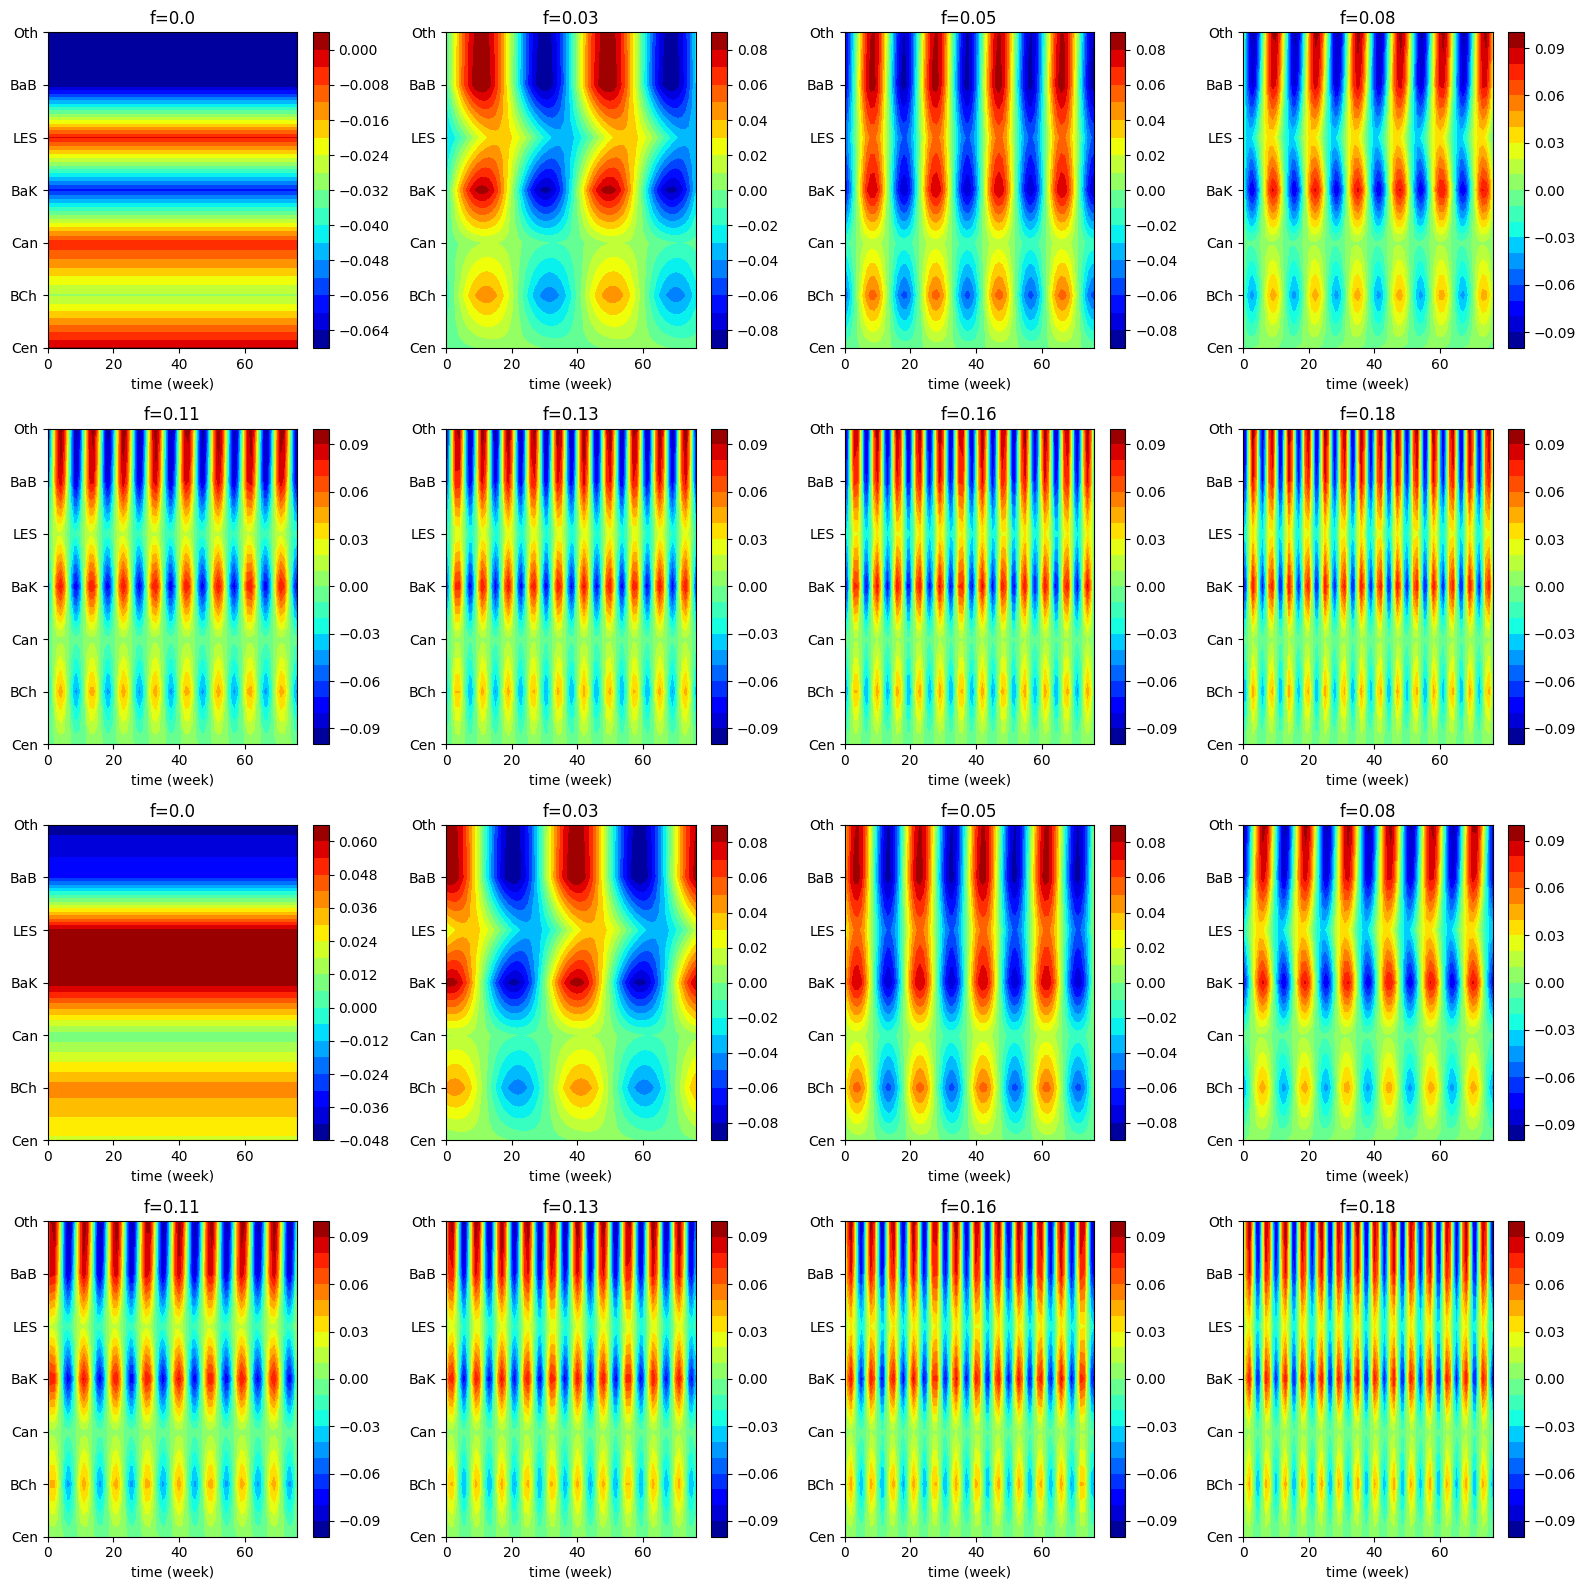

In [46]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
NFFF = 0
for NF in range(0, 15, 2):
    ax = axes[0, NFFF] if NF <= 6 else axes[1, NFFF - 4]
    cf = ax.contourf(np.reshape(EP[:, 0, NF], (WW, D)).T, 20, cmap='jet')
    plt.colorbar(cf, ax=ax); ax.set_title(f'f={round(fE2[NF], 2)}')
    ax.set_xlabel('time (week)'); ax.set_yticks(range(D))
    ax.set_yticklabels(['Cen', 'BCh', 'Can', 'BaK', 'LES', 'BaB', 'Oth'][:D])
    ax.tick_params(labelsize=10); NFFF += 1

NFFF = 0
for NF in range(0, 15, 2):
    ax = axes[2, NFFF] if NF <= 6 else axes[3, NFFF - 4]
    cf = ax.contourf(np.reshape(EP[:, 1, NF], (WW, D)).T, 20, cmap='jet')
    plt.colorbar(cf, ax=ax); ax.set_title(f'f={round(fE2[NF], 2)}')
    ax.set_xlabel('time (week)'); ax.set_yticks(range(D))
    ax.set_yticklabels(['Cen', 'BCh', 'Can', 'BaK', 'LES', 'BaB', 'Oth'][:D])
    ax.tick_params(labelsize=10); NFFF += 1
plt.tight_layout(); plt.show()

### MSLM Forecast
Run Multi-Level Stochastic Stuart-Landau Model over 20 frequency bins with 600 ensemble members. NF=0 uses linear model; NF>0 uses Stuart-Landau with symmetry and nonlinear constraints.

In [47]:
NFS_fcst = 0
NFE_fcst = 20
NT0      = 600
inorm    = 1; ires = 0; iSYM = 1; iNL = 1; inEQ = 1; L_lvl = 2

NA  = X.shape[0] - EP.shape[0] // D + 1
NE  = NA + LEAD
NXT = NE + EP.shape[0] // D - 1
print(f"NA={NA}, NE={NE}, NXT={NXT}, LEAD={LEAD}")

RXT = np.zeros((NXT, DD, NFE_fcst - NFS_fcst, NT0))
RRT = np.zeros((X.shape[0], DD, NFE_fcst - NFS_fcst))
AXT = np.zeros((NE, 2, NT0, NFE_fcst - NFS_fcst))
np.random.seed(0)

print("Running MSLM forecast...")
for NF in range(NFS_fcst, NFE_fcst):
    print(f"  NF={NF+1}/{NFE_fcst}")
    NM = D if NF == 0 else 2 * D
    ncmp = NM; ER = EP[:, :NM, NF]; A = dahc(X, ER)
    indm = np.arange(ncmp)
    RR_f = hrc(A, ER, DD, indm); n = min(RR_f.shape[0], X.shape[0])
    RRT[:n, :, NF - NFS_fcst] = RR_f[:n, :]
    DMD = A[:, indm]
    np.random.seed(0)
    if ires == 0:
        indrandperm = np.random.randn(ncmp, NE, NT0)
    else:
        indrandperm = np.zeros((NA - 1, NT0), dtype=int)
        for nt in range(NT0):
            indrandperm[:, nt] = np.random.permutation(NA - 1)
    if NF == 0:
        xx, xt_res, LL, _ = MSLM_FCST(LEAD, DMD, 0, L_lvl, NT0, ires, inorm, 0, 0, 0, indrandperm)
    else:
        xx, xt_res, LL, ENL = MSLM_FCST(LEAD, DMD, 1, L_lvl, NT0, ires, inorm, iSYM, iNL, inEQ, indrandperm)
    AXT[:, :2, :, NF - NFS_fcst] = xx[:NE, :2, :]
    RXZ = np.zeros((NXT, DD, NT0))
    for KK in range(NT0):
        RXZ[:min(xx.shape[0], NXT), :, KK] = hrc(
            xx[:, indm, KK], ER[:, indm], DD, np.arange(A[:, indm].shape[1])
        )[:min(xx.shape[0], NXT), :]
    RXT[:, :, NF - NFS_fcst, :] = RXZ
print("Forecast complete!")

NA=963, NE=899, NXT=975, LEAD=-64
Running MSLM forecast...
  NF=1/20
  NF=2/20


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  NF=3/20
  NF=4/20
  NF=5/20
  NF=6/20
  NF=7/20
  NF=8/20
  NF=9/20
  NF=10/20
  NF=11/20
  NF=12/20
  NF=13/20
  NF=14/20
  NF=15/20
  NF=16/20
  NF=17/20
  NF=18/20
  NF=19/20
  NF=20/20
Forecast complete!


### Post-Processing
Sum across frequencies, add back seasonal cycle and mean, zero negative SIE.

In [48]:
NET  = X.shape[0]
indf = np.arange(NFE_fcst - NFS_fcst)
RR   = np.sum(RRT[:, :, indf], axis=2)
RX   = np.sum(RXT[:, :, indf, :], axis=2)

if icycle == 1:
    for j in range(DD):
        for i in range(52):
            idx = np.arange(i, RR.shape[0], 52); idx = idx[idx < RR.shape[0]]
            RR[idx, j] += scycle[i, j]
            for k in range(NT0):
                idx2 = np.arange(i, RX.shape[0], 52); idx2 = idx2[idx2 < RX.shape[0]]
                RX[idx2, j, k] += scycle[i, j]

RX0 = RX.copy()
tmp = icemean
for k in range(NT0): RX0[:, :, k] += tmp
RX0[RX0 < 0] = 0
RX00 = RX0.copy()
for k in range(NT0): RX00[:, :, k] -= tmp

RXRC  = np.sum(RXT[:, :, indf, :], axis=2)
RXC   = np.squeeze(np.sum(RXRC, axis=1))
RXRMC = np.squeeze(np.sum(np.mean(RXT[:, :, indf, :], axis=3), axis=2))
RXMC  = np.sum(RXRMC, axis=1)
RXX   = np.squeeze(np.sum(RX, axis=1))
print(f"Post-processing complete. RXRC shape: {RXRC.shape}")

Post-processing complete. RXRC shape: (975, 7, 600)


### Fig 5 — Forecast vs Observations
Cyan = ensemble members, red = ensemble mean, black = observed anomalies (ROBSRF).

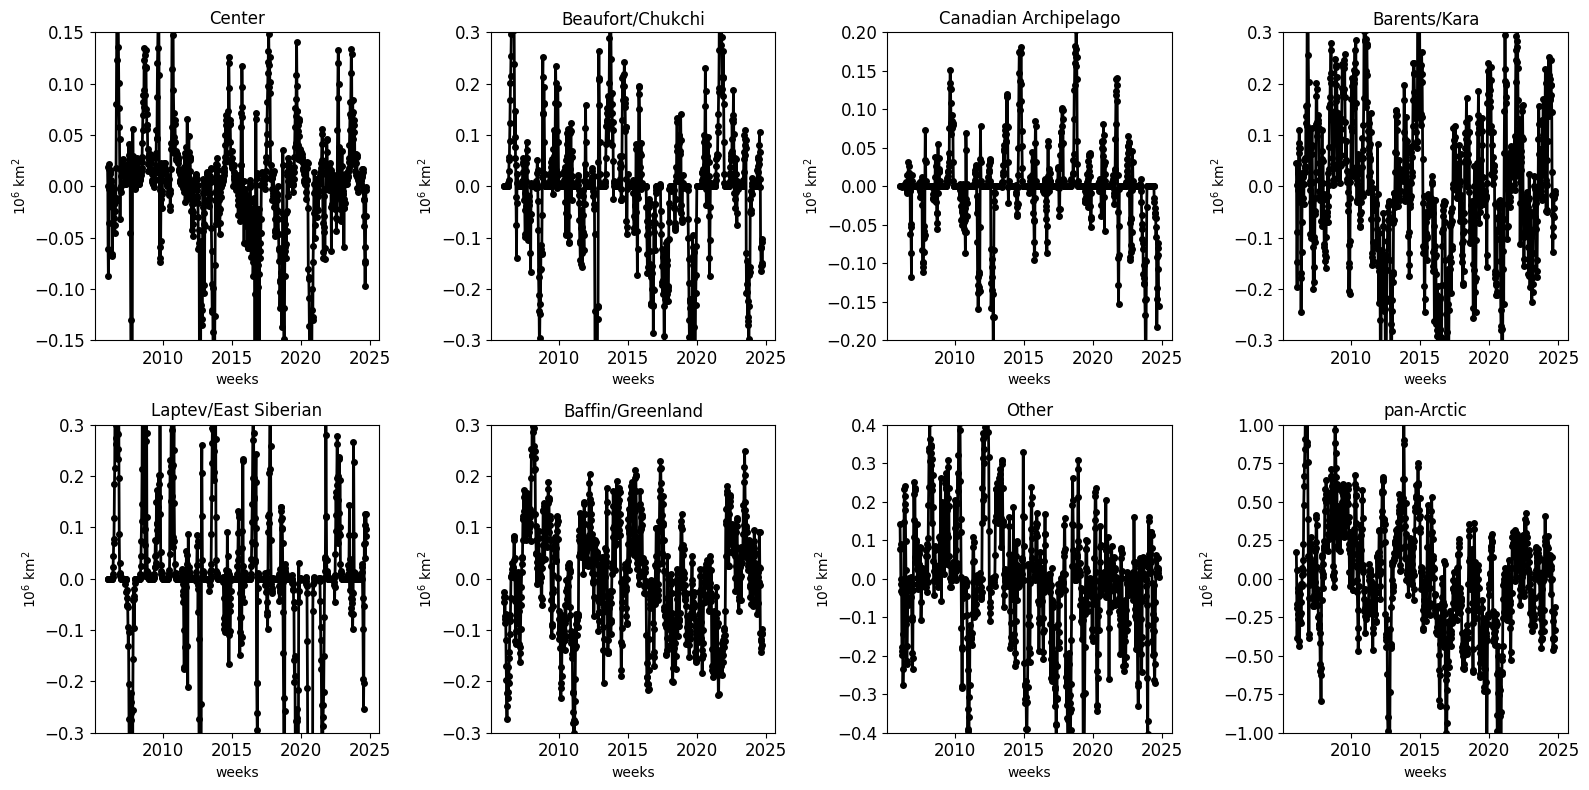

NET_plot=962, LEAD=-64, RXRC shape=(975, 7, 600)
Forecast window: 2024.52 to 2023.29


In [51]:
# ── Fig 5 — Forecast vs Observations ─────────────────────────────────────────
mat    = scipy.io.loadmat('ROBSF.mat')
ROBSF  = mat['ROBSF'].ravel()
ROBSRF = mat['ROBSRF']

lmax   = RXRC.shape[0]
t_full = yearst_full[:lmax]

# Forecast starts at NA (number of DAHCs), not KT
NET_plot = NA - 1   # start of forecast in RXRC array

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
ylims2 = [(-0.15, 0.15), (-0.3, 0.3), (-0.2, 0.2),
          (-0.3, 0.3),   (-0.3, 0.3), (-0.3, 0.3), (-0.4, 0.4)]

for kk in range(DD):
    ax = axes.flat[kk]
    # Ensemble members (cyan)
    ax.plot(t_full[NET_plot:NET_plot + LEAD + 1],
            np.squeeze(RXRC[NET_plot:NET_plot + LEAD + 1, kk, :]) / 1e6,
            'c-', linewidth=1)
    # Ensemble mean (red)
    ax.plot(t_full[NET_plot:NET_plot + LEAD + 1],
            RXRMC[NET_plot:NET_plot + LEAD + 1, kk] / 1e6,
            'r.-', markersize=8, linewidth=2)
    # Observations (black)
    ax.plot(t_full[:min(len(ROBSRF), lmax)],
            ROBSRF[:min(len(ROBSRF), lmax), kk] / 1e6,
            'k.-', markersize=8, linewidth=2)
    ax.set_title(titles[kk] if kk < len(titles) else f'Region {kk+1}')
    if kk < len(ylims2): ax.set_ylim(ylims2[kk])
    ax.set_xlabel('weeks'); ax.set_ylabel('10$^6$ km$^2$')
    ax.tick_params(labelsize=12)

ax = axes.flat[7]
ax.plot(t_full[NET_plot:NET_plot + LEAD + 1],
        RXC[NET_plot:NET_plot + LEAD + 1, :] / 1e6, 'c-', linewidth=1)
ax.plot(t_full[NET_plot:NET_plot + LEAD + 1],
        RXMC[NET_plot:NET_plot + LEAD + 1]   / 1e6, 'r.-', markersize=8, linewidth=2)
ax.plot(t_full[:min(len(ROBSF), lmax)], ROBSF[:min(len(ROBSF), lmax)] / 1e6,
        'k.-', markersize=8, linewidth=2)
ax.set_title('pan-Arctic'); ax.set_ylim([-1, 1])
ax.set_xlabel('weeks'); ax.set_ylabel('10$^6$ km$^2$')
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

print(f"NET_plot={NET_plot}, LEAD={LEAD}, RXRC shape={RXRC.shape}")
print(f"Forecast window: {t_full[NET_plot]:.2f} to {t_full[min(NET_plot+LEAD, lmax-1)]:.2f}")

### September Prediction and Histogram

September indices: [974 974 974 974]
September years: [2024.75 2024.75 2024.75 2024.75]
SeptSIE (Mkm2): 15.1174


/var/folders/xl/xr37p5hn1vjf5bvdbd5hm8q80000gn/T/ipykernel_89873/196190054.py:45: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim([xlim_lo, xlim_hi])


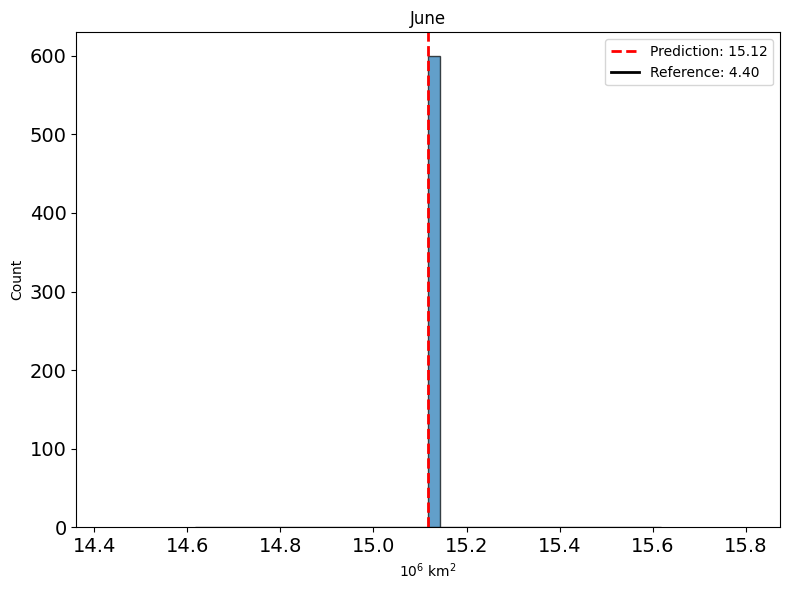

In [53]:
# ── September prediction ──────────────────────────────────────────────────────
# September = weeks 36-39 of the year
# Find week 36-39 in the forecast window
# yearst_full values: 2006 + week/52
# September target year = last year in data + 1

# Use the forecast window directly
# RXRC goes from 0 to NXT-1; forecast starts at NA-1
# September is week 36-39 → find those indices in yearst_full

year_target = int(yearst_full[NA - 1]) + 1   # next year after forecast start
sept_weeks  = [year_target + w/52 for w in range(36, 40)]

# Find closest indices in yearst_full
lmax = RXRC.shape[0]
sept = []
for sw in sept_weeks:
    idx = np.argmin(np.abs(yearst_full[:lmax] - sw))
    if idx < lmax:
        sept.append(idx)
sept = np.array(sept)
print(f"September indices: {sept}")
print(f"September years: {yearst_full[sept]}")

tmppp  = np.squeeze(np.sum(RX0, axis=1))       # (NXT, NT0)
tmppp1 = tmppp + np.sum(icemean)
tmppp2 = np.mean(tmppp1[sept, :], axis=0) / 1e6
sice   = np.mean(tmppp2)
uns    = np.std(RXX, axis=1, ddof=1)

print(f'SeptSIE (Mkm2): {sice:.4f}')

# Auto-scale histogram based on actual data range
p5, p95 = np.percentile(tmppp2, 5), np.percentile(tmppp2, 95)
margin  = (p95 - p5) * 0.5
xlim_lo = max(0, p5 - margin)
xlim_hi = p95 + margin

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(tmppp2, bins=40, edgecolor='black', alpha=0.7)
ax.axvline(sice, color='r', linestyle='--', linewidth=2,
           label=f'Prediction: {sice:.2f}')
ax.axvline(4.40, color='k', linestyle='-', linewidth=2,
           label='Reference: 4.40')
ax.set_xlim([xlim_lo, xlim_hi])
ax.set_xlabel('10$^6$ km$^2$'); ax.set_ylabel('Count')
ax.set_title('June'); ax.legend(); ax.tick_params(labelsize=14)
plt.tight_layout()
plt.show()